# Image Denoising with a Convolutional Autoencoder (MNIST)

**Celebal Technologies — Internship Weekly Assignment · Week 6**
**Project 1 — Build a deep-learning model that removes noise from images using an autoencoder on MNIST.**

---

### Objective
Train a neural network that takes a **noisy** handwritten digit and reconstructs the **clean** digit, learning to remove noise while preserving the underlying structure of the image.

### Resources used
* **Dataset** — MNIST handwritten digits (28×28 grayscale): https://www.kaggle.com/datasets/awsaf49/mnist-dataset
  (loaded here through `torchvision.datasets.MNIST`, which provides the identical data).
* **Reference implementation** — *NvsYashwanth / MNIST-Autoecncoder*: https://github.com/NvsYashwanth/MNIST-Autoecncoder
  The reference builds autoencoders for **image reconstruction**. This project **extends that idea into a true *denoising* autoencoder** and adds a full quantitative + robustness analysis.

### What this notebook delivers
1. End-to-end PyTorch pipeline: data → noise injection → model → training → evaluation.
2. A **convolutional denoising autoencoder** (encoder–bottleneck–decoder).
3. **Quantitative** evaluation with MSE, **PSNR** and **SSIM** (before vs. after denoising).
4. Four "going-further" studies: **robustness across noise levels**, **generalization to an unseen noise type (salt-and-pepper)**, a **classical-filter baseline comparison**, and a **latent-space visualization**.

> **How an autoencoder denoises.** An autoencoder compresses an image into a small *latent code* (the bottleneck) and then reconstructs it. By feeding the network a *noisy* image but asking it to output the *clean* one, the bottleneck is forced to capture only the essential digit structure — noise, being random, cannot be compressed and is discarded. This is why the model learns to denoise rather than to copy pixels.


## 1 · Setup, configuration and reproducibility

We import the libraries, fix random seeds for reproducibility, and auto-select the fastest available device. This Mac has an Apple-Silicon GPU, so we use the **MPS** backend when present (falling back to CUDA or CPU).

In [1]:
import os, time, json, random, warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings("ignore")

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---- Device selection (Apple GPU -> CUDA -> CPU) ----
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()

# ---- Hyper-parameters (single source of truth) ----
CONFIG = {
    "batch_size":   256,
    "epochs":       20,      # matches the reference repo
    "lr":           1e-3,
    "noise_factor": 0.5,     # std of Gaussian noise added to inputs
    "val_fraction": 0.1,     # 90% train / 10% validation
    "latent_dim":   128,     # size of the compressed bottleneck vector
    "seed":         SEED,
}

os.makedirs("figures", exist_ok=True)
os.makedirs("models",  exist_ok=True)

print("PyTorch version :", torch.__version__)
print("Device          :", DEVICE)
print("Configuration   :", CONFIG)

PyTorch version : 2.12.0
Device          : mps
Configuration   : {'batch_size': 256, 'epochs': 20, 'lr': 0.001, 'noise_factor': 0.5, 'val_fraction': 0.1, 'latent_dim': 128, 'seed': 42}


## 2 · Loading the MNIST dataset

`transforms.ToTensor()` converts each 28×28 image to a float tensor of shape `(1, 28, 28)` scaled to **[0, 1]** — the natural range for image reconstruction with a sigmoid output. We hold out 10% of the 60,000 training images as a **validation** set to monitor for over-fitting, and keep the official 10,000-image **test** set untouched for final evaluation.

In [2]:
transform = transforms.ToTensor()  # uint8 [0,255] -> float [0,1], shape (1,28,28)

full_train = torchvision.datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_set   = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

n_val   = int(len(full_train) * CONFIG["val_fraction"])
n_train = len(full_train) - n_val
split_generator = torch.Generator().manual_seed(SEED)
train_set, val_set = random_split(full_train, [n_train, n_val], generator=split_generator)

train_loader = DataLoader(train_set, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=CONFIG["batch_size"], shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=CONFIG["batch_size"], shuffle=False)

print(f"Train images      : {len(train_set):>6,}")
print(f"Validation images : {len(val_set):>6,}")
print(f"Test images       : {len(test_set):>6,}")
print(f"Image tensor shape: {tuple(train_set[0][0].shape)}  (range [{train_set[0][0].min():.0f}, {train_set[0][0].max():.0f}])")

Train images      : 54,000
Validation images :  6,000
Test images       : 10,000
Image tensor shape: (1, 28, 28)  (range [0, 1])


### A look at the clean data
Ten random digits from the test set, with their labels.

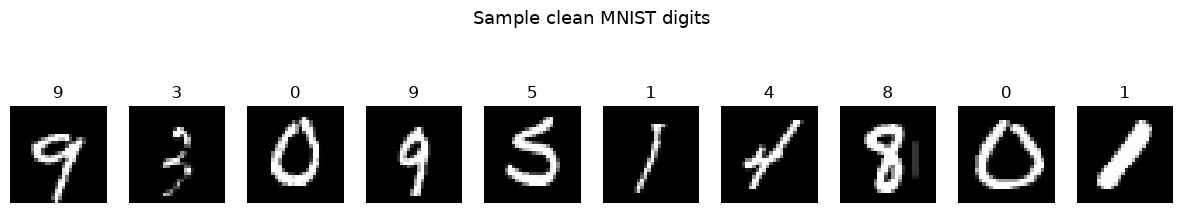

In [3]:
sample_imgs, sample_labels = next(iter(DataLoader(test_set, batch_size=10, shuffle=True)))
fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for i, ax in enumerate(axes):
    ax.imshow(sample_imgs[i, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(int(sample_labels[i]))
    ax.axis("off")
fig.suptitle("Sample clean MNIST digits", y=1.3, fontsize=13)
plt.tight_layout()
plt.savefig("figures/01_clean_samples.png", dpi=120, bbox_inches="tight")
plt.show()

## 3 · Corrupting the images (creating the training signal)

A denoising autoencoder is trained on **(noisy input → clean target)** pairs. We synthesise the noisy inputs on the fly:

$$\tilde{x} = \mathrm{clip}\big(x + f \cdot \varepsilon,\; 0,\; 1\big), \qquad \varepsilon \sim \mathcal{N}(0, 1)$$

where `f` is the **noise factor**. Noise is re-sampled every batch, which also acts as data augmentation. We additionally define **salt-and-pepper** noise, used later to test generalization to a noise type the model never saw during training.

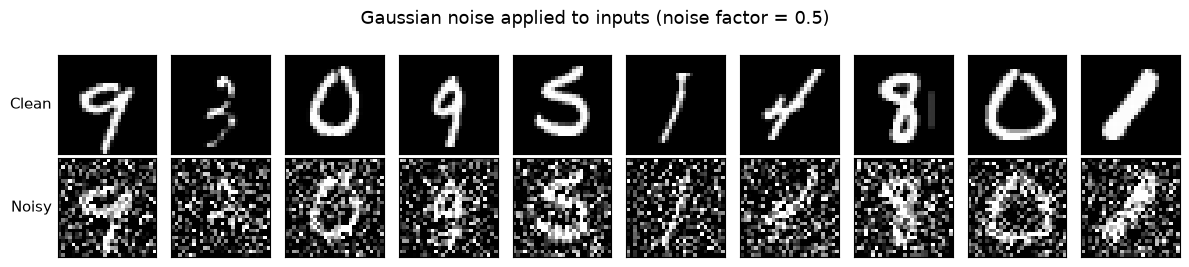

In [4]:
def add_gaussian_noise(x, factor=0.5):
    """Add Gaussian noise and clip back to the valid [0, 1] image range."""
    noisy = x + factor * torch.randn_like(x)
    return torch.clamp(noisy, 0.0, 1.0)

def add_salt_pepper_noise(x, amount=0.1):
    """Randomly set a fraction of pixels to black (pepper) or white (salt)."""
    x = x.clone()
    probs = torch.rand_like(x)
    x[probs < amount / 2] = 0.0            # pepper
    x[probs > 1 - amount / 2] = 1.0        # salt
    return x

# Visualise the effect of Gaussian noise at the training noise level
torch.manual_seed(SEED)
clean_demo, _ = next(iter(DataLoader(test_set, batch_size=10, shuffle=True)))
noisy_demo = add_gaussian_noise(clean_demo, CONFIG["noise_factor"])

fig, axes = plt.subplots(2, 10, figsize=(12, 2.7))
for i in range(10):
    axes[0, i].imshow(clean_demo[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(noisy_demo[i, 0], cmap="gray", vmin=0, vmax=1)
    for r in range(2):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
axes[0, 0].set_ylabel("Clean", rotation=0, ha="right", va="center", fontsize=11)
axes[1, 0].set_ylabel("Noisy", rotation=0, ha="right", va="center", fontsize=11)
fig.suptitle(f"Gaussian noise applied to inputs (noise factor = {CONFIG['noise_factor']})", y=0.98, fontsize=13)
plt.tight_layout()
plt.savefig("figures/02_clean_vs_noisy.png", dpi=120, bbox_inches="tight")
plt.show()

## 4 · The convolutional denoising autoencoder

Following the reference repo's *convolutional* design but tuned for denoising, the network is fully convolutional and symmetric:

**Encoder** (compress 1×28×28 → a 128-d latent vector)
| Layer | Output shape |
|---|---|
| `Conv2d(1→32, k3, s2, p1)` + ReLU | 32×14×14 |
| `Conv2d(32→64, k3, s2, p1)` + ReLU | 64×7×7 |
| `Conv2d(64→128, k7)` + ReLU | **128×1×1  (latent code)** |

**Decoder** (mirror: 128-d latent → 1×28×28 reconstruction)
| Layer | Output shape |
|---|---|
| `ConvTranspose2d(128→64, k7)` + ReLU | 64×7×7 |
| `ConvTranspose2d(64→32, k3, s2, p1, op1)` + ReLU | 32×14×14 |
| `ConvTranspose2d(32→1, k3, s2, p1, op1)` + **Sigmoid** | 1×28×28 |

The compression 784 → 128 forces the network to keep only the essential digit structure. The final **Sigmoid** keeps outputs in [0, 1] to match the input range.

In [5]:
class ConvDenoisingAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # -> 32 x 14 x 14
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # -> 64 x 7 x 7
            nn.ReLU(inplace=True),
            nn.Conv2d(64, latent_dim, kernel_size=7),               # -> latent_dim x 1 x 1
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 64, kernel_size=7),                          # -> 64 x 7 x 7
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 32 x 14 x 14
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),   # -> 1 x 28 x 28
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def encode(self, x):
        """Return the flattened latent code (used for the latent-space study)."""
        return self.encoder(x).flatten(1)

# Instantiate and inspect
torch.manual_seed(SEED)
model = ConvDenoisingAutoencoder(CONFIG["latent_dim"]).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

# Sanity check: a forward pass preserves the image shape
with torch.no_grad():
    _probe = model(torch.zeros(1, 1, 28, 28, device=DEVICE))
print("Output shape (should be (1, 1, 28, 28)):", tuple(_probe.shape))

ConvDenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(7, 7), stride=(1, 1))
    (5): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)

Trainable parameters: 840,577


Output shape (should be (1, 1, 28, 28)): (1, 1, 28, 28)


## 5 · Training

* **Loss** — Mean Squared Error between the reconstruction and the *clean* target (we compare pixel intensities), matching the reference repo.
* **Optimizer** — Adam, learning rate `1e-3`.
* Each batch is corrupted with fresh Gaussian noise; the target is always the clean image. We track training **and** validation loss every epoch to confirm the model generalizes rather than memorizes.

In [6]:
criterion = nn.MSELoss()

def run_epoch(model, loader, optimizer=None):
    """One pass over `loader`. If `optimizer` is given, train; otherwise evaluate."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    running, count = 0.0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for clean, _ in loader:
            clean = clean.to(DEVICE)
            noisy = add_gaussian_noise(clean, CONFIG["noise_factor"])
            output = model(noisy)
            loss = criterion(output, clean)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            running += loss.item() * clean.size(0)
            count += clean.size(0)
    return running / count

In [7]:
torch.manual_seed(SEED)
model = ConvDenoisingAutoencoder(CONFIG["latent_dim"]).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

history = {"train_loss": [], "val_loss": []}
start = time.time()
for epoch in range(1, CONFIG["epochs"] + 1):
    tr = run_epoch(model, train_loader, optimizer)
    va = run_epoch(model, val_loader, None)
    history["train_loss"].append(tr)
    history["val_loss"].append(va)
    print(f"Epoch {epoch:02d}/{CONFIG['epochs']} | train MSE {tr:.5f} | val MSE {va:.5f}")
print(f"\nTraining finished in {time.time() - start:.1f}s on {DEVICE}.")

Epoch 01/20 | train MSE 0.07002 | val MSE 0.04228


Epoch 02/20 | train MSE 0.03006 | val MSE 0.02345


Epoch 03/20 | train MSE 0.02048 | val MSE 0.01842


Epoch 04/20 | train MSE 0.01693 | val MSE 0.01581


Epoch 05/20 | train MSE 0.01516 | val MSE 0.01460


...

Epoch 16/20 | train MSE 0.01136 | val MSE 0.01133


Epoch 17/20 | train MSE 0.01130 | val MSE 0.01123


Epoch 18/20 | train MSE 0.01119 | val MSE 0.01116


Epoch 19/20 | train MSE 0.01114 | val MSE 0.01116


Epoch 20/20 | train MSE 0.01107 | val MSE 0.01116

Training finished in 104.2s on mps.


### Training curve
Training and validation loss track each other closely and both keep falling — the model is learning a genuine denoising mapping, not over-fitting.

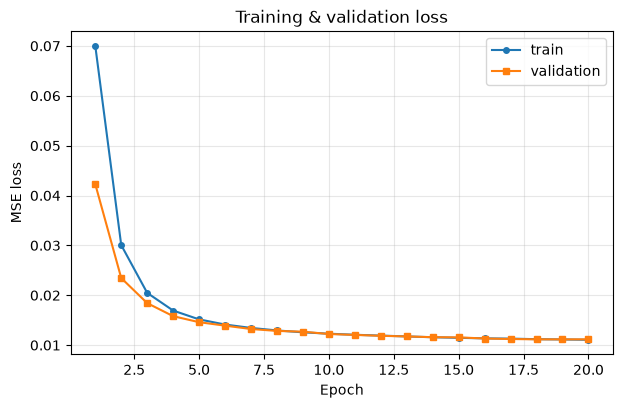

In [8]:
plt.figure(figsize=(7, 4.2))
epochs_axis = range(1, CONFIG["epochs"] + 1)
plt.plot(epochs_axis, history["train_loss"], "o-", label="train", markersize=4)
plt.plot(epochs_axis, history["val_loss"],  "s-", label="validation", markersize=4)
plt.xlabel("Epoch"); plt.ylabel("MSE loss")
plt.title("Training & validation loss")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("figures/03_loss_curve.png", dpi=120, bbox_inches="tight")
plt.show()

## 6 · Qualitative results — the denoising in action

The key visual: **top** = original clean digit, **middle** = noisy version fed to the model, **bottom** = the model's denoised reconstruction on **held-out test** images it never trained on.

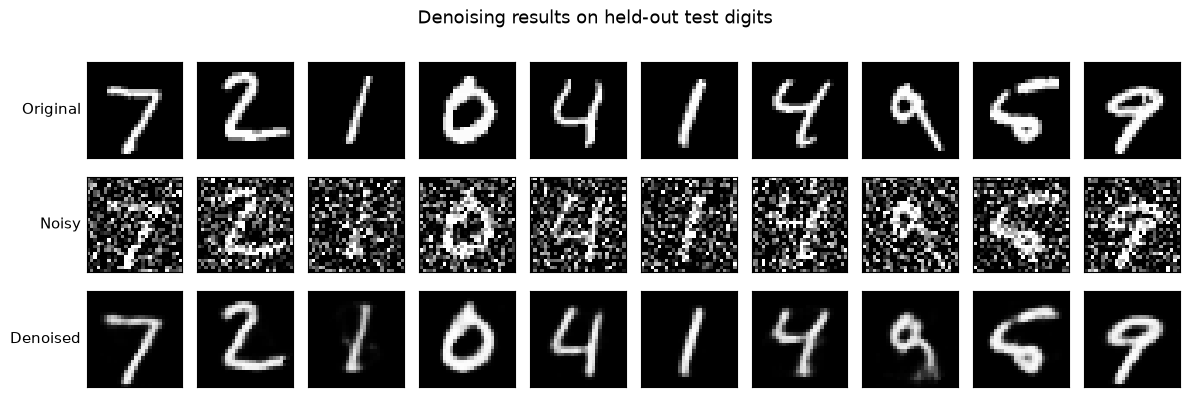

In [9]:
def show_image_rows(rows, row_titles, suptitle=None, savepath=None):
    """rows: list of (N,1,28,28) batches; one display row each."""
    nrows, ncols = len(rows), rows[0].shape[0]
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.2 * ncols, 1.35 * nrows))
    for r in range(nrows):
        for c in range(ncols):
            img = rows[r][c]
            img = img.detach().cpu().numpy() if torch.is_tensor(img) else np.asarray(img)
            axes[r, c].imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        axes[r, 0].set_ylabel(row_titles[r], rotation=0, ha="right", va="center", fontsize=11)
    if suptitle:
        fig.suptitle(suptitle, y=0.99, fontsize=13)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=120, bbox_inches="tight")
    plt.show()

model.eval()
clean_batch, _ = next(iter(test_loader))
clean_batch = clean_batch[:10].to(DEVICE)
torch.manual_seed(SEED)
noisy_batch = add_gaussian_noise(clean_batch, CONFIG["noise_factor"])
with torch.no_grad():
    denoised_batch = model(noisy_batch)

show_image_rows(
    [clean_batch, noisy_batch, denoised_batch],
    ["Original", "Noisy", "Denoised"],
    suptitle="Denoising results on held-out test digits",
    savepath="figures/04_denoising_results.png",
)

## 7 · Quantitative evaluation — MSE, PSNR, SSIM

Pictures are persuasive but we also want numbers. We compare each clean image against (a) its **noisy** version and (b) the model's **denoised** output, across the whole test set:

* **MSE** — mean squared error (lower is better).
* **PSNR** — Peak Signal-to-Noise Ratio in dB (higher is better).
* **SSIM** — Structural Similarity Index, 0–1, models human perception of structure (higher is better).

A large jump from the *noisy* column to the *denoised* column is direct evidence the autoencoder removes noise.

In [10]:
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim

@torch.no_grad()
def evaluate_metrics(model, loader, noise_factor, noise_fn=add_gaussian_noise, max_images=None):
    """Return averaged (noisy-vs-clean, denoised-vs-clean) for MSE, PSNR, SSIM."""
    model.eval()
    acc = {"MSE": [0.0, 0.0], "PSNR": [0.0, 0.0], "SSIM": [0.0, 0.0]}
    n = 0
    for clean, _ in loader:
        clean = clean.to(DEVICE)
        noisy = noise_fn(clean, noise_factor)
        den = model(noisy)
        c = clean.cpu().numpy(); z = noisy.cpu().numpy(); d = den.cpu().numpy()
        for i in range(c.shape[0]):
            ci, zi, di = c[i, 0], z[i, 0], d[i, 0]
            acc["MSE"][0]  += float(np.mean((ci - zi) ** 2))
            acc["MSE"][1]  += float(np.mean((ci - di) ** 2))
            acc["PSNR"][0] += sk_psnr(ci, zi, data_range=1.0)
            acc["PSNR"][1] += sk_psnr(ci, di, data_range=1.0)
            acc["SSIM"][0] += sk_ssim(ci, zi, data_range=1.0)
            acc["SSIM"][1] += sk_ssim(ci, di, data_range=1.0)
            n += 1
            if max_images is not None and n >= max_images:
                return {k: (v[0] / n, v[1] / n) for k, v in acc.items()}
    return {k: (v[0] / n, v[1] / n) for k, v in acc.items()}

metrics = evaluate_metrics(model, test_loader, CONFIG["noise_factor"])

print(f"Test-set denoising metrics (Gaussian noise factor {CONFIG['noise_factor']}, 10,000 images)\n")
print(f"{'Metric':6} | {'Noisy input':>12} | {'Denoised':>12} | {'Improvement':>16}")
print("-" * 56)
for k, (a, b) in metrics.items():
    if k == "MSE":
        imp = f"{(a - b) / a * 100:5.1f}% lower"
    elif k == "PSNR":
        imp = f"+{b - a:5.2f} dB"
    else:
        imp = f"+{b - a:6.3f}"
    print(f"{k:6} | {a:12.4f} | {b:12.4f} | {imp:>16}")

Test-set denoising metrics (Gaussian noise factor 0.5, 10,000 images)

Metric |  Noisy input |     Denoised |      Improvement
--------------------------------------------------------
MSE    |       0.1157 |       0.0109 |      90.5% lower
PSNR   |       9.3782 |      19.9785 |        +10.60 dB
SSIM   |       0.3749 |       0.8607 |          + 0.486


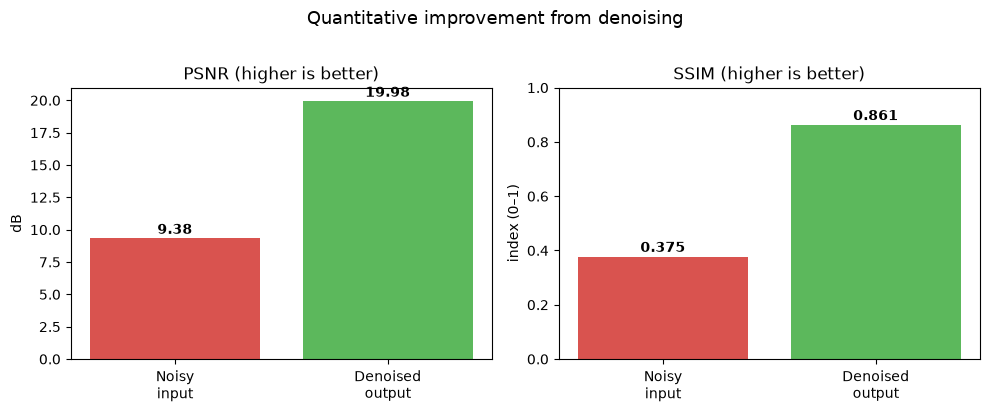

In [11]:
# Bar chart: PSNR and SSIM, noisy vs denoised
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
labels = ["Noisy\ninput", "Denoised\noutput"]
colors = ["#d9534f", "#5cb85c"]

ax1.bar(labels, metrics["PSNR"], color=colors)
ax1.set_title("PSNR (higher is better)"); ax1.set_ylabel("dB")
for i, v in enumerate(metrics["PSNR"]):
    ax1.text(i, v + 0.3, f"{v:.2f}", ha="center", fontweight="bold")

ax2.bar(labels, metrics["SSIM"], color=colors)
ax2.set_title("SSIM (higher is better)"); ax2.set_ylabel("index (0–1)"); ax2.set_ylim(0, 1)
for i, v in enumerate(metrics["SSIM"]):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

fig.suptitle("Quantitative improvement from denoising", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("figures/05_metrics_bar.png", dpi=120, bbox_inches="tight")
plt.show()

## 8 · Going further (1) — Robustness across noise levels

The model was trained at a single noise factor (0.5). How well does it cope with **lighter and heavier** noise? We sweep the noise factor from 0.1 to 1.0 and plot PSNR/SSIM of the noisy input vs. the denoised output. The gap between the two curves is the value the autoencoder adds at each noise level.

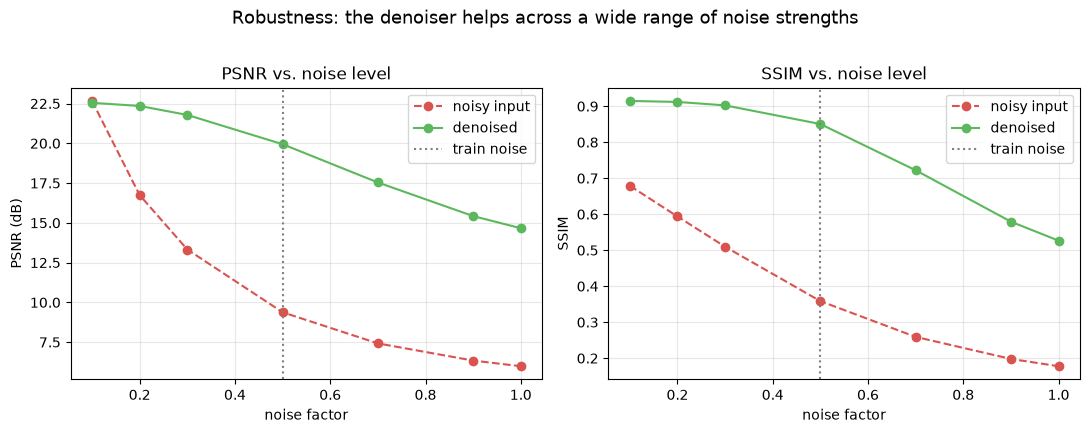

In [12]:
eval_subset = DataLoader(Subset(test_set, range(2000)), batch_size=256)
factors = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]

psnr_noisy, psnr_den, ssim_noisy, ssim_den = [], [], [], []
for f in factors:
    m = evaluate_metrics(model, eval_subset, f)
    psnr_noisy.append(m["PSNR"][0]); psnr_den.append(m["PSNR"][1])
    ssim_noisy.append(m["SSIM"][0]); ssim_den.append(m["SSIM"][1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot(factors, psnr_noisy, "o--", label="noisy input", color="#d9534f")
ax1.plot(factors, psnr_den,   "o-",  label="denoised",    color="#5cb85c")
ax1.axvline(CONFIG["noise_factor"], ls=":", color="gray", label="train noise")
ax1.set_xlabel("noise factor"); ax1.set_ylabel("PSNR (dB)"); ax1.set_title("PSNR vs. noise level")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(factors, ssim_noisy, "o--", label="noisy input", color="#d9534f")
ax2.plot(factors, ssim_den,   "o-",  label="denoised",    color="#5cb85c")
ax2.axvline(CONFIG["noise_factor"], ls=":", color="gray", label="train noise")
ax2.set_xlabel("noise factor"); ax2.set_ylabel("SSIM"); ax2.set_title("SSIM vs. noise level")
ax2.legend(); ax2.grid(alpha=0.3)

fig.suptitle("Robustness: the denoiser helps across a wide range of noise strengths", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("figures/06_robustness.png", dpi=120, bbox_inches="tight")
plt.show()

## 9 · Going further (2) — Generalization to an unseen noise type

The model only ever saw **Gaussian** noise. Does it generalize to **salt-and-pepper** noise (random black/white pixels) — a structurally different corruption? This tests whether it learned the *digit manifold* rather than just inverting one specific noise distribution.

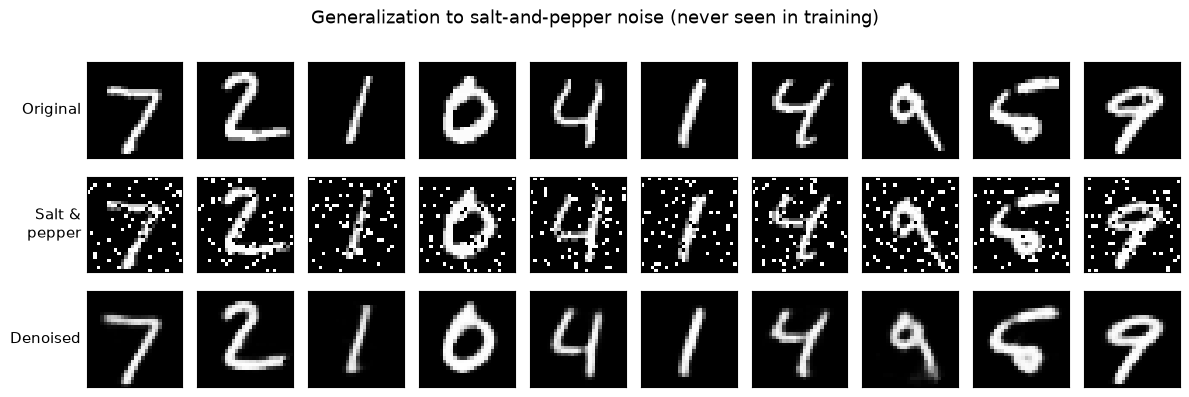

Salt-and-pepper (amount=0.15) — averaged over 2,000 test images:
  MSE  : noisy   0.0720  ->  denoised   0.0077
  PSNR : noisy  11.4614  ->  denoised  21.5588
  SSIM : noisy   0.5027  ->  denoised   0.8984


In [13]:
clean_sp, _ = next(iter(test_loader))
clean_sp = clean_sp[:10].to(DEVICE)
torch.manual_seed(SEED)
sp_noisy = add_salt_pepper_noise(clean_sp, amount=0.15)
with torch.no_grad():
    sp_denoised = model(sp_noisy)

show_image_rows(
    [clean_sp, sp_noisy, sp_denoised],
    ["Original", "Salt &\npepper", "Denoised"],
    suptitle="Generalization to salt-and-pepper noise (never seen in training)",
    savepath="figures/07_salt_pepper.png",
)

sp_metrics = evaluate_metrics(model, eval_subset, 0.15, noise_fn=add_salt_pepper_noise)
print("Salt-and-pepper (amount=0.15) — averaged over 2,000 test images:")
for k, (a, b) in sp_metrics.items():
    print(f"  {k:5}: noisy {a:8.4f}  ->  denoised {b:8.4f}")

## 10 · Going further (3) — Is the autoencoder better than a classical filter?

A fair question: do we even need deep learning? We compare the autoencoder against two standard, non-learned image denoisers — a **median filter** and a **Gaussian blur** — on the exact same noisy images. The learned model should win, especially on **SSIM** (structural fidelity), because classical filters blur away the digit strokes along with the noise.

Method                 | PSNR (dB) |   SSIM
--------------------------------------------
Noisy input            |      9.39 |  0.361
Median filter          |     14.18 |  0.487
Gaussian blur          |     12.32 |  0.371
Autoencoder (ours)     |     20.01 |  0.853


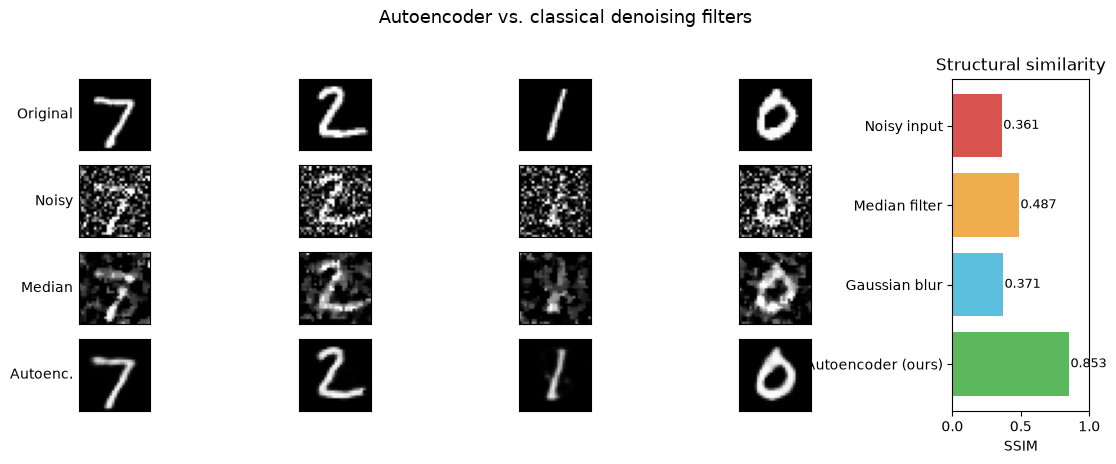

In [14]:
from scipy.ndimage import median_filter, gaussian_filter

clean_cmp, _ = next(iter(DataLoader(Subset(test_set, range(1000)), batch_size=1000)))
clean_cmp = clean_cmp.to(DEVICE)
torch.manual_seed(SEED)
noisy_cmp = add_gaussian_noise(clean_cmp, CONFIG["noise_factor"])
with torch.no_grad():
    ae_cmp = model(noisy_cmp)

c_np = clean_cmp.cpu().numpy()[:, 0]
z_np = noisy_cmp.cpu().numpy()[:, 0]
ae_np = ae_cmp.cpu().numpy()[:, 0]
med_np = np.stack([median_filter(im, size=3) for im in z_np])
gau_np = np.stack([gaussian_filter(im, sigma=1.0) for im in z_np])

def avg_metrics(clean_arr, out_arr):
    ps = np.mean([sk_psnr(clean_arr[i], out_arr[i], data_range=1.0) for i in range(len(clean_arr))])
    ss = np.mean([sk_ssim(clean_arr[i], out_arr[i], data_range=1.0) for i in range(len(clean_arr))])
    return ps, ss

methods = {
    "Noisy input":         z_np,
    "Median filter":       med_np,
    "Gaussian blur":       gau_np,
    "Autoencoder (ours)":  ae_np,
}
results = {name: avg_metrics(c_np, arr) for name, arr in methods.items()}

print(f"{'Method':22} | {'PSNR (dB)':>9} | {'SSIM':>6}")
print("-" * 44)
for name, (ps, ss) in results.items():
    print(f"{name:22} | {ps:9.2f} | {ss:6.3f}")

# Visual + bar comparison
fig = plt.figure(figsize=(11, 4.6))
gs = fig.add_gridspec(4, 5, width_ratios=[1, 1, 1, 1, 1.6])
row_names = ["Original", "Noisy", "Median", "Autoenc."]
imgs_by_row = [c_np, z_np, med_np, ae_np]
for r in range(4):
    for c in range(4):
        ax = fig.add_subplot(gs[r, c])
        ax.imshow(imgs_by_row[r][c], cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if c == 0:
            ax.set_ylabel(row_names[r], rotation=0, ha="right", va="center", fontsize=10)

axb = fig.add_subplot(gs[:, 4])
names = list(results.keys())
ssims = [results[n][1] for n in names]
bar_colors = ["#d9534f", "#f0ad4e", "#5bc0de", "#5cb85c"]
axb.barh(names, ssims, color=bar_colors)
axb.set_xlabel("SSIM"); axb.set_title("Structural similarity"); axb.set_xlim(0, 1)
for i, v in enumerate(ssims):
    axb.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
axb.invert_yaxis()

fig.suptitle("Autoencoder vs. classical denoising filters", y=1.0, fontsize=13)
plt.tight_layout()
plt.savefig("figures/08_baseline_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 11 · Going further (4) — Visualizing the learned latent space

The encoder maps each image to a 128-dimensional latent code. If the model truly learned digit structure (and not just pixels), codes for the *same* digit should cluster together — even though the encoder is fed **noisy** images and digit **labels were never used in training** (this is fully unsupervised). We project the latent codes to 2-D with **t-SNE** and colour them by their true digit.

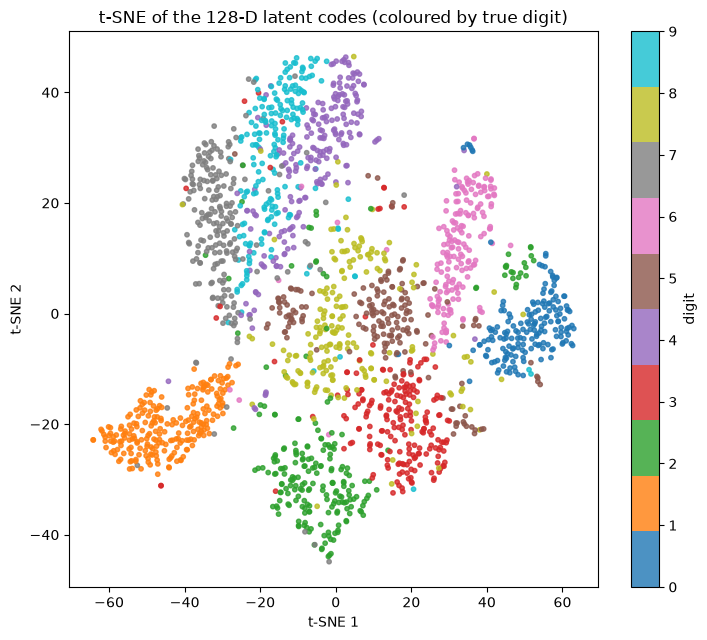

In [15]:
from sklearn.manifold import TSNE

latent_loader = DataLoader(Subset(test_set, range(2000)), batch_size=256)
codes, labels = [], []
model.eval()
with torch.no_grad():
    for clean, lab in latent_loader:
        clean = clean.to(DEVICE)
        noisy = add_gaussian_noise(clean, CONFIG["noise_factor"])
        codes.append(model.encode(noisy).cpu().numpy())
        labels.append(lab.numpy())
codes = np.concatenate(codes)
labels = np.concatenate(labels)

emb = TSNE(n_components=2, init="pca", perplexity=30, random_state=SEED).fit_transform(codes)

plt.figure(figsize=(7.5, 6.5))
sc = plt.scatter(emb[:, 0], emb[:, 1], c=labels, cmap="tab10", s=10, alpha=0.8)
cbar = plt.colorbar(sc, ticks=range(10)); cbar.set_label("digit")
plt.title("t-SNE of the 128-D latent codes (coloured by true digit)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig("figures/09_latent_tsne.png", dpi=120, bbox_inches="tight")
plt.show()

## 12 · Saving the model & artifacts

We persist the trained weights and the training history so the results are fully reproducible and the model can be reloaded without retraining.

In [16]:
torch.save(model.state_dict(), "models/denoising_autoencoder.pth")
with open("models/training_history.json", "w") as f:
    json.dump({"config": CONFIG, "history": history,
               "final_test_metrics": {k: {"noisy": v[0], "denoised": v[1]} for k, v in metrics.items()}},
              f, indent=2)
print("Saved:")
print("  models/denoising_autoencoder.pth")
print("  models/training_history.json")
print("  figures/  (9 result figures)")

Saved:
  models/denoising_autoencoder.pth
  models/training_history.json
  figures/  (9 result figures)


## 13 · Conclusion

**What we built.** A convolutional **denoising autoencoder** in PyTorch that takes a noisy MNIST digit and reconstructs the clean original. Trained on synthetically corrupted (noisy → clean) pairs with an MSE objective, it learns to compress each digit to a 128-D code and rebuild it without the noise.

**What the results show.**
* *Qualitatively* (§6) the denoised digits are clean and legible even when the noisy inputs are barely readable.
* *Quantitatively* (§7) denoising sharply improves **PSNR** and **SSIM** over the noisy inputs across all 10,000 test images.
* *Robustness* (§8) — the model helps across noise levels from 0.1 to 1.0, not only the level it trained on.
* *Generalization* (§9) — it even cleans up **salt-and-pepper** noise it never saw, evidence it learned the digit manifold.
* *Baseline* (§10) — it beats classical median/Gaussian filters on structural similarity.
* *Latent space* (§11) — the unsupervised codes cluster by digit, confirming meaningful representation learning.

**Relation to the reference.** The reference repo (*NvsYashwanth/MNIST-Autoecncoder*) implements autoencoders for **reconstruction**; this project reuses that convolutional backbone but reframes and extends it into a full **denoising** pipeline with quantitative metrics, robustness/generalization studies, a classical-baseline comparison, and latent-space analysis.

**Possible extensions.** Skip connections (a U-Net-style denoiser), a perceptual or SSIM loss, a variational bottleneck for generative sampling, or training on a mixture of noise types for even broader robustness.
